## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras
import correlator
import physicsHelper
import lossCalculator
import models

2024-11-26 14:56:57.803965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-26 14:56:57.804512: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 14:56:57.806571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 14:56:57.811838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732629417.820949   28293 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732629417.82

In [2]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

(0.0, 10.0)

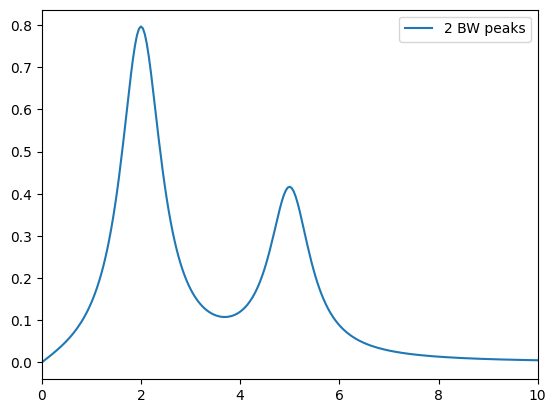

In [3]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)

# plt.plot(omega,spec1BW,label=r'1 BW peak')
plt.plot(omega,spec2BW, label=r'2 BW peaks')
#plt.plot(omega,spec3BW, label=r'3 BW peaks')

plt.legend()
plt.xlim(0,10)


In [4]:
# Constructing the training data - preparing the discrete kernel 
# Following the paper with grid of Np=25 and Nw=500
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

In [5]:
# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

2024-11-26 14:56:59.547630: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


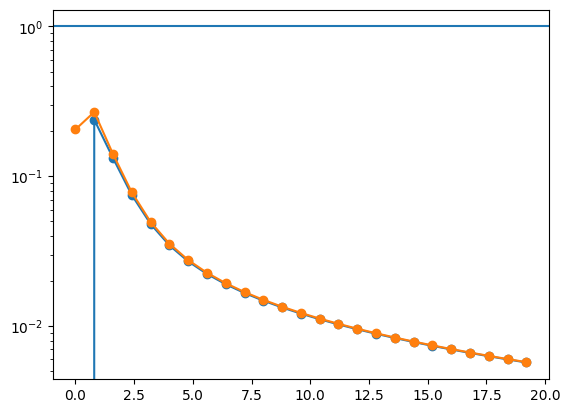

In [6]:
plt.plot(x,(Dxi*(x))/del_xi,marker='o',label='Dxi')
plt.plot(x,(Dxi*(x+1e-1))/del_xi,marker='o',label='Dxi shifted')
plt.axhline(1)
plt.yscale('log')

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

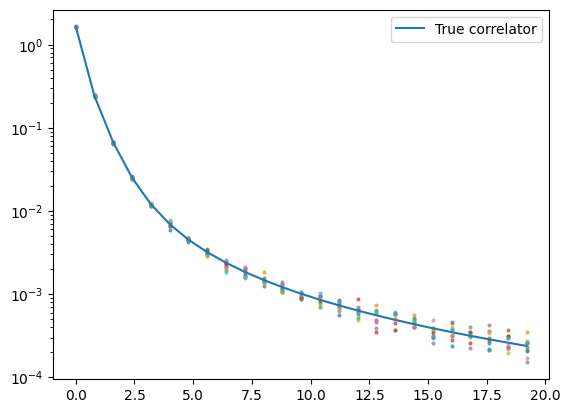

In [7]:
# Preparing the tensor of noise vectors
ep_noise=1e-2
noisy_dxi_tensor = []
num_samples = 10
for ii in range(num_samples):
    noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
    noisy_dxi_tensor.append(noisy_Dxi)


plt.plot(x,Dxi, label=r'True correlator')
for i in range(len(noisy_dxi_tensor)):
    plt.scatter(x, noisy_dxi_tensor[i], s=4, alpha=0.6)

plt.yscale('log')

plt.legend()

In [8]:
custom_std/custom_std.numpy()[0]

<tf.Tensor: shape=(25,), dtype=float32, numpy=
array([1.        , 1.3068799 , 0.68462   , 0.38028327, 0.24137291,
       0.17274247, 0.13447507, 0.11053854, 0.09414382, 0.08214551,
       0.07293558, 0.06561387, 0.05963647, 0.05465376, 0.05042982,
       0.04679906, 0.04364147, 0.04086781, 0.03841026, 0.03621621,
       0.03424426, 0.03246133, 0.03084066, 0.02936037, 0.02800237],
      dtype=float32)>

In [ ]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-4
lambda_l2 = 1.0e-4
gauss_width = np.ones(len(x)) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
kern=klW_ker_Pos
model = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
lossCalc=lossCalculator.LossCalculator(model=model,
                                       y_true=target_output,
                                       kernel=kern,
                                       delomega=del_omega,
                                       x=constant_input,
                                       std=gauss_width,
                                       lambda_s_func_warmup=lambda x:lambda_s,
                                       lambda_s_func=lambda x:1.0e-6,
                                       lambda_l2_func_warmup=lambda x:lambda_l2,
                                       lambda_l2_func=lambda x:1.0e-8
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)

trainer=models.networkTrainer(model,optimizer,lossCalc)

epochs=2000

total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)


optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer

new_epochs = 10000

total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

print("Training complete for additional epochs.")



Training for 2000 epochs
Epoch 0, Loss: 751.3434448242188
Epoch 200, Loss: 0.05269206315279007
Epoch 400, Loss: 0.0082575473934412
Epoch 600, Loss: 0.0029380987398326397
Epoch 800, Loss: 0.0022816702257841825
Epoch 1000, Loss: 0.002210729755461216
Epoch 1200, Loss: 0.002197397407144308
Epoch 1400, Loss: 0.0021841658744961023
Epoch 1600, Loss: 0.002161304233595729
Epoch 1800, Loss: 0.00208304519765079
Training took 14.414241075515747 seconds
Training for 10000 epochs
Epoch 0, Loss: 0.0015401494456455112
Epoch 1000, Loss: 0.0008086524903774261
Epoch 2000, Loss: 0.00018000458658207208
Epoch 3000, Loss: 6.43556413706392e-05
Epoch 4000, Loss: 2.23677543544909e-05
Epoch 5000, Loss: 9.03670115803834e-06
Epoch 6000, Loss: 5.495957339007873e-06
Epoch 7000, Loss: 4.274357252143091e-06
Epoch 8000, Loss: 3.6198275665810797e-06
Epoch 9000, Loss: 3.2561804346187273e-06
Training took 72.09947919845581 seconds
Training complete for additional epochs.


In [9]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-4
lambda_l2 = 1.0e-4
# gauss_width = np.ones(len(x)) #for mean square error
gauss_width = custom_std #for chi square error

# Initialize the model
kern=klW_ker_Pos
model_stderror = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
lossCalc=lossCalculator.LossCalculator(model=model_stderror,
                                       y_true=target_output,
                                       kernel=kern,
                                       delomega=del_omega,
                                       x=constant_input,
                                       std=gauss_width,
                                       lambda_s_func_warmup=lambda x:lambda_s,
                                       lambda_s_func=lambda x:1.0e-6,
                                       lambda_l2_func_warmup=lambda x:lambda_l2,
                                       lambda_l2_func=lambda x:1.0e-8
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)

trainer=models.networkTrainer(model_stderror,optimizer,lossCalc)

epochs=2000

total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)


optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer

new_epochs = 5000

total_loss_history_stderror,loss_history_stderror=trainer.train(new_epochs,warmup=False,verbose=True)

print("Training complete for additional epochs.")



Training for 2000 epochs
Epoch 0, Loss: 751.8138427734375
Epoch 200, Loss: 0.06237817928195
Epoch 400, Loss: 0.009881380945444107
Epoch 600, Loss: 0.0028991559520363808
Epoch 800, Loss: 0.0018957519205287099
Epoch 1000, Loss: 0.0017568327020853758
Epoch 1200, Loss: 0.0017047690926119685
Epoch 1400, Loss: 0.0015315557830035686
Epoch 1600, Loss: 0.0015013067750260234
Epoch 1800, Loss: 0.0014863486867398024
Training took 14.263686895370483 seconds
Training for 5000 epochs
Epoch 0, Loss: 0.0014680871972814202
Epoch 500, Loss: 0.0012215767055749893
Epoch 1000, Loss: 0.0007757585262879729
Epoch 1500, Loss: 0.00032401582575403154
Epoch 2000, Loss: 0.00010411004768684506
Epoch 2500, Loss: 4.0170813008444384e-05
Epoch 3000, Loss: 1.8646798707777634e-05
Epoch 3500, Loss: 1.1040522622352e-05
Epoch 4000, Loss: 8.887413059710525e-06
Epoch 4500, Loss: 8.31629313324811e-06
Training took 35.4097466468811 seconds
Training complete for additional epochs.


In [12]:
# Final_rhoWNoisy = model(constant_input).numpy().reshape(-1)
# Final_DxiWNoisy = correlator.Di(kern,Final_rhoWNoisy,del_omega).numpy().reshape(-1)


Final_rhoWNoisy_stderror = model_stderror(constant_input).numpy().reshape(-1)
Final_DxiWNoisy_stderror = correlator.Di(kern,Final_rhoWNoisy_stderror,del_omega).numpy().reshape(-1)
# Final_rhoWNoisySingle = model(constant_input).numpy().reshape(-1)
# Final_DpiWNoisySingle = correlator.Di(kern,Final_rhoWNoisySingle,del_omega).numpy().reshape(-1)

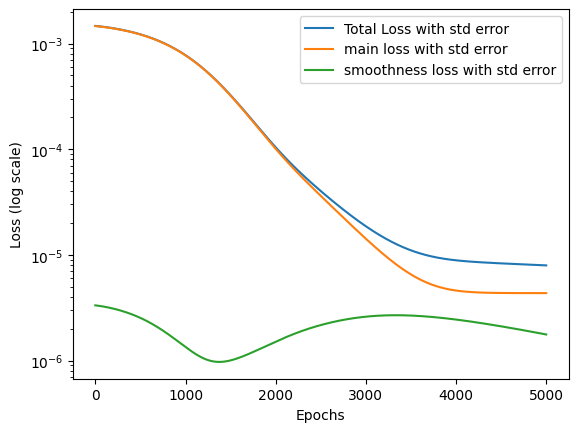

In [10]:
# Plotting loss history
# loss_history = np.array(loss_history)
loss_history_stderror = np.array(loss_history_stderror)
# plt.plot(range(new_epochs), total_loss_history
#          , label='Total Loss')
# plt.plot(range(new_epochs), loss_history.T[0],label="main loss")
# plt.plot(range(new_epochs), loss_history.T[1]*lossCalc.get_lambda_s(range(new_epochs),warmup=False),label="smoothness loss")
# plt.plot(range(new_epochs), 0.5*loss_history.T[2]*lossCalc.get_lambda_l2(range(new_epochs),warmup=False),label="L2 loss")

plt.plot(range(new_epochs), total_loss_history_stderror, label='Total Loss with std error')
plt.plot(range(new_epochs), loss_history_stderror.T[0],label="main loss with std error")
plt.plot(range(new_epochs), loss_history_stderror.T[1]*lossCalc.get_lambda_s(range(new_epochs),warmup=False),label="smoothness loss with std error")
# plt.plot(range(new_epochs), 0.5*loss_history_stderror.T[2]*lossCalc.get_lambda_l2(range(new_epochs),warmup=False),label="L2 loss with std error")

plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.yscale('log') 
# plt.ylim(np.min(loss_history.T[0])/10,1e-5)
plt.legend()
#plt.title('Training Loss Over Epochs 1BW with mean square')
#plt.savefig('NN_Training_loss_1peak_10K.png')
plt.show()

/tmp/ipykernel_28293/4109638618.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label = r'True function' )


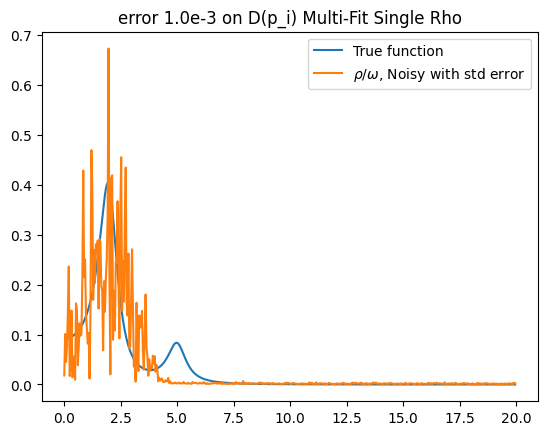

In [13]:
plt.plot(omega,spec2BW/omega, label = r'True function' )
# plt.plot(omega,Final_rhoW, label=r'$\rho/\omega * \omega$')
# plt.plot(omega,Final_rhoWSingle, label=r'$\rho/\omega * \omega$, Single')
# plt.plot(omega,Final_rhoWNoisy, label=r'$\rho/\omega$, Noisy')
plt.plot(omega,Final_rhoWNoisy_stderror, label=r'$\rho/\omega$, Noisy with std error')
# plt.plot(omega,Final_rhoWNoisySingle, label=r'$\rho/\omega$, Noisy Single')
# plt.plot(omega,Final_rho, label=r'$\rho$')
plt.title(r'error 1.0e-3 on D(p_i) Multi-Fit Single Rho')
plt.legend()
#plt.savefig('NN_Comparison_RhoByOmega_vs_Rho_MultiFitSingleRho10m3.png')
plt.show()

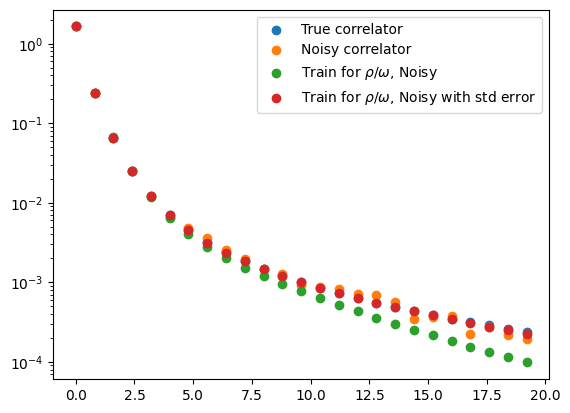

In [23]:
plt.scatter(x,Dxi, label=r'True correlator')
plt.scatter(x,noisy_dxi_tensor[0], label=r'Noisy correlator')
# plt.scatter(p,Final_DpiW, label=r'Train for $\rho/\omega$')
# plt.scatter(p,Final_DpiWSingle, label=r'Train for $\rho/\omega$, Single')
plt.scatter(x,Final_DxiWNoisy, label=r'Train for $\rho/\omega$, Noisy')
plt.scatter(x,Final_DxiWNoisy_stderror, label=r'Train for $\rho/\omega$, Noisy with std error')
# plt.scatter(p,Final_DpiWNoisySingle, label=r'Train for $\rho/\omega$, Noisy Single')
# plt.scatter(p,Final_Dpi, label=r'Train for $\rho$')
#plt.ylim(0.0,0.004)
plt.yscale('log')
#plt.xlim(10,20)

#plt.title('1 BW Peak 5000 epochs error 1e-3')
plt.legend()
#plt.savefig('NN_ComparisonDpi_RhoByOmega_vs_Rho_MultiFitSingleRho10m3.png')
plt.show()

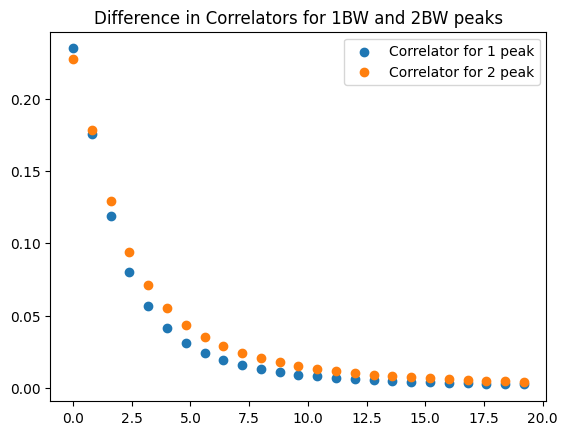

In [ ]:
plt.scatter(p,Dpi1, label=r'Correlator for 1 peak')
plt.scatter(p,Dpi2, label=r'Correlator for 2 peak')
plt.title('Difference in Correlators for 1BW and 2BW peaks')
plt.legend()
#plt.savefig('Comparison_Correlators.png')
plt.show()

In [ ]:
Ath = tf.ones([25], dtype=tf.float32)
Bth = 2.0*tf.ones([25], dtype=tf.float32)
Cth = 5.0*np.ones(25)


In [ ]:
(Ath-Bth)/Cth

<tf.Tensor: shape=(25,), dtype=float32, numpy=
array([-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2,
       -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2,
       -0.2, -0.2, -0.2], dtype=float32)>

In [ ]:
Cth[2]

1.0

# Behaviour of the kernal with $\omega$ and $p$.  

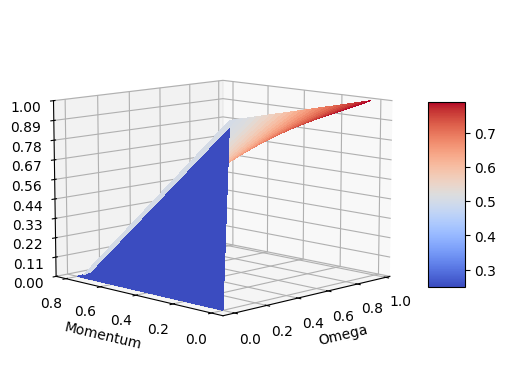

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [ ]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [ ]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [ ]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

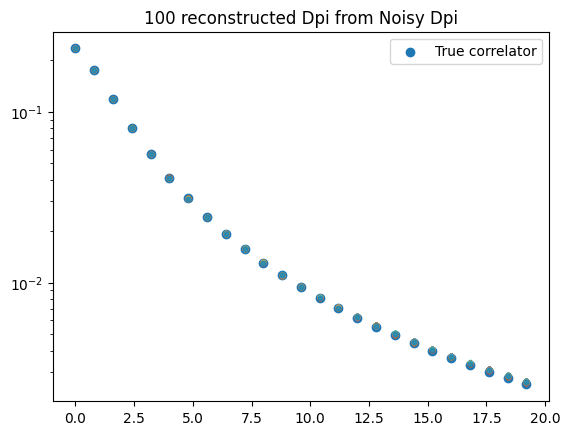

In [ ]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

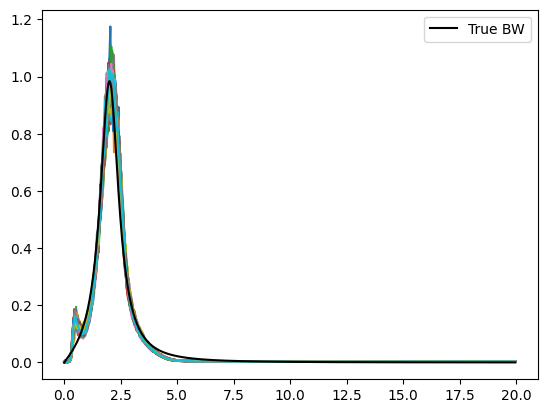

In [ ]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [ ]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [ ]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

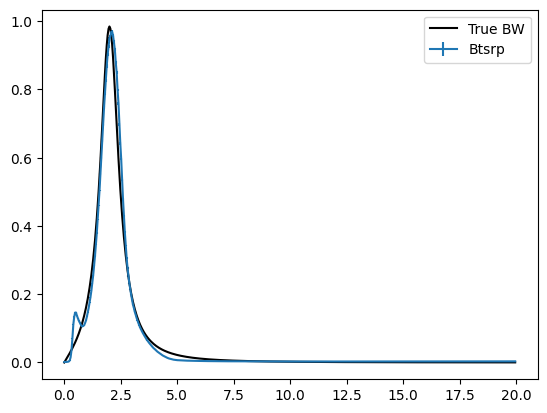

In [ ]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()